# 🔍 EDA: AI vs Real Images Dataset (v2 — Fixed)

**Dataset structure (actual):**
```
versions/1/
  real_dataset/
    city/ | nature/ | animals/ | people/ | food/
  Ai_generated_dataset/
    city/ | nature/ | animals/ | people/ | food/
```
Two labels: `real_dataset` and `Ai_generated_dataset`  
Five categories per label: city, nature, animals, people, food

## 1. Setup & Imports

In [11]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path          # Path objects support / operator for joining paths
from tqdm.auto import tqdm
from scipy import stats
import cv2

import kagglehub

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('All imports successful ✅')

All imports successful ✅


## 2. Download Dataset & Fix the Path

**The fix:** `kagglehub.dataset_download()` returns a plain `str` like `'/Users/.../versions/1'`.  
We wrap it in `Path()` so we can use the `/` operator to join subfolders.  

```python
# This FAILS — str / str is not defined
path = '/some/folder'
path / 'subfolder'   # ❌ TypeError

# This WORKS — Path supports / for joining
path = Path('/some/folder')
path / 'subfolder'   # ✅ Returns Path('/some/folder/subfolder')
```

In [2]:
raw_path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
DATASET_PATH = Path(raw_path)   # <-- THE FIX: wrap in Path()

print(f"Dataset path: {DATASET_PATH}")
print(f"Type: {type(DATASET_PATH)}")
print(f"\nTop-level folders:")
for item in sorted(DATASET_PATH.iterdir()):
    print(f"  📂 {item.name}/")
    for sub in sorted(item.iterdir()) if item.is_dir() else []:
        n = len([f for f in sub.iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png','.webp'}])
        print(f"      📁 {sub.name}/ → {n} images")

Dataset path: /Users/bestek/.cache/kagglehub/datasets/rhythmghai/ai-vs-real-images-dataset/versions/1
Type: <class 'pathlib._local.PosixPath'>

Top-level folders:
  📂 Ai_generated_dataset/
      📁 animals/ → 50 images
      📁 city/ → 50 images
      📁 food/ → 50 images
      📁 nature/ → 50 images
      📁 people/ → 50 images
  📂 real_dataset/
      📁 animals/ → 148 images
      📁 city/ → 150 images
      📁 food/ → 150 images
      📁 nature/ → 150 images
      📁 people/ → 147 images


## 3. Build the Image Inventory DataFrame

Now we know the structure, we'll iterate correctly:  
- **Level 1 folders** = label (`real_dataset`, `Ai_generated_dataset`)  
- **Level 2 folders** = category (`city`, `nature`, `animals`, `people`, `food`)  

We capture both — category is useful for understanding *what kinds* of images are hardest to classify.

In [3]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

# Clean label names for readability
LABEL_MAP = {
    'real_dataset': 'Real',
    'Ai_generated_dataset': 'AI'
}

records = []

for label_folder in sorted(DATASET_PATH.iterdir()):
    if not label_folder.is_dir():
        continue
    label = LABEL_MAP.get(label_folder.name, label_folder.name)
    
    for category_folder in sorted(label_folder.iterdir()):
        if not category_folder.is_dir():
            continue
        category = category_folder.name
        
        for img_path in category_folder.iterdir():
            if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    'path': str(img_path),
                    'filename': img_path.name,
                    'label': label,
                    'category': category,
                    'ext': img_path.suffix.lower()
                })

df = pd.DataFrame(records)
print(f"✅ Total images: {len(df):,}")
print(f"Labels: {df['label'].unique()}")
print(f"Categories: {df['category'].unique()}")
print()
df.head(8)

✅ Total images: 995
Labels: ['AI' 'Real']
Categories: ['animals' 'city' 'food' 'nature' 'people']



,path,filename,label,category,ext
0,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-46.png,AI,animals,.png
1,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-9.png,AI,animals,.png
2,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-8.png,AI,animals,.png
3,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-47.png,AI,animals,.png
4,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-45.png,AI,animals,.png
5,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-50.png,AI,animals,.png
6,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-44.png,AI,animals,.png
7,/Users/bestek/.cache/kagglehub/datasets/rhythm...,image-40.png,AI,animals,.png


## 4. Class & Category Distribution

**Key question:** Are AI and Real images balanced overall, AND within each category?  
An imbalanced dataset will make the model lazy — it'll just learn to predict the majority class.

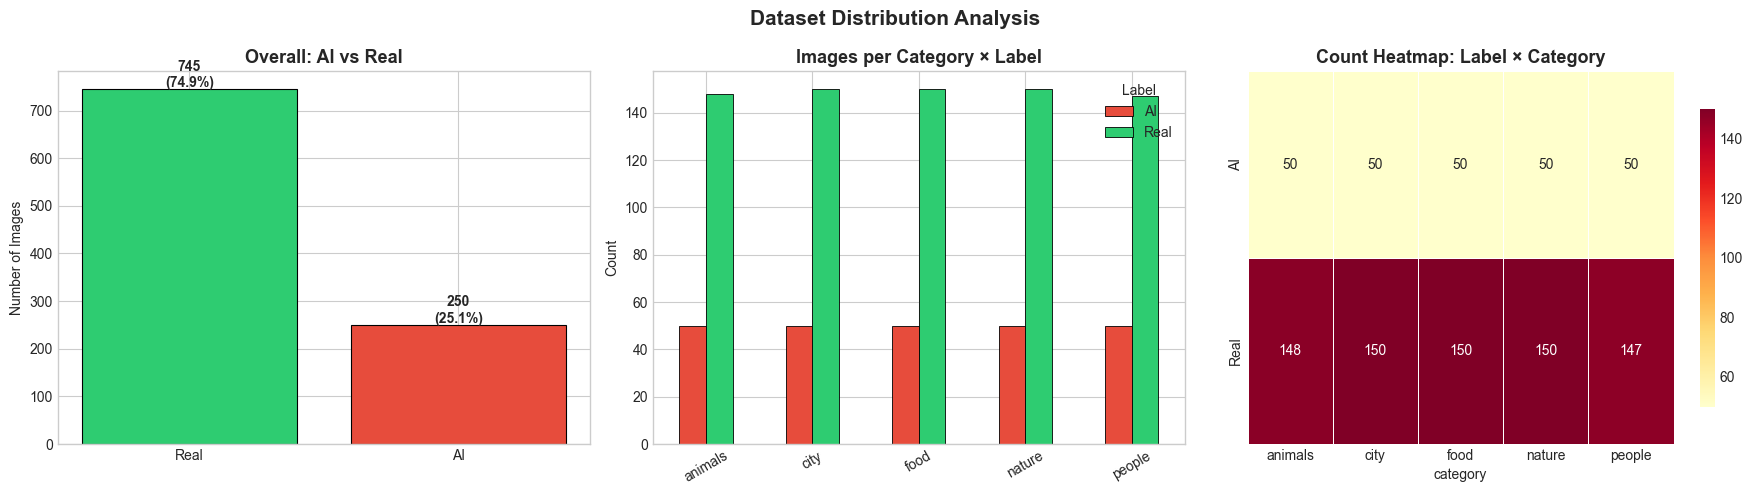


⚖️  Overall class ratio (majority / minority): 2.98x
⚠️  Significant imbalance! Real images outnumber AI images ~3:1.
   → Use class_weight='balanced' in sklearn, or weighted loss in PyTorch/Keras.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Overall label counts ---
label_counts = df['label'].value_counts()
colors = ['#2ECC71' if l == 'Real' else '#E74C3C' for l in label_counts.index]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Overall: AI vs Real', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for bar, count in zip(bars, label_counts.values):
    pct = count / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

# --- Plot 2: Category counts per label (grouped bar) ---
cat_label = df.groupby(['category', 'label']).size().unstack(fill_value=0)
cat_label.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#2ECC71'],
               edgecolor='black', linewidth=0.6)
axes[1].set_title('Images per Category × Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label')

# --- Plot 3: Heatmap — count by label × category ---
pivot = df.groupby(['label', 'category']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[2].set_title('Count Heatmap: Label × Category', fontsize=13, fontweight='bold')
axes[2].set_ylabel('')

plt.suptitle('Dataset Distribution Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Imbalance check
ratio = label_counts.max() / label_counts.min()
print(f"\n⚖️  Overall class ratio (majority / minority): {ratio:.2f}x")
if ratio > 1.5:
    print("⚠️  Significant imbalance! Real images outnumber AI images ~3:1.")
    print("   → Use class_weight='balanced' in sklearn, or weighted loss in PyTorch/Keras.")
else:
    print("✅ Balanced enough for standard training.")

## 5. Sample Images — Visual Sanity Check

**Always look at your data.** We'll show a grid organized by label AND category.  
This helps answer: *Do AI images look obviously fake? Or is it subtle?*

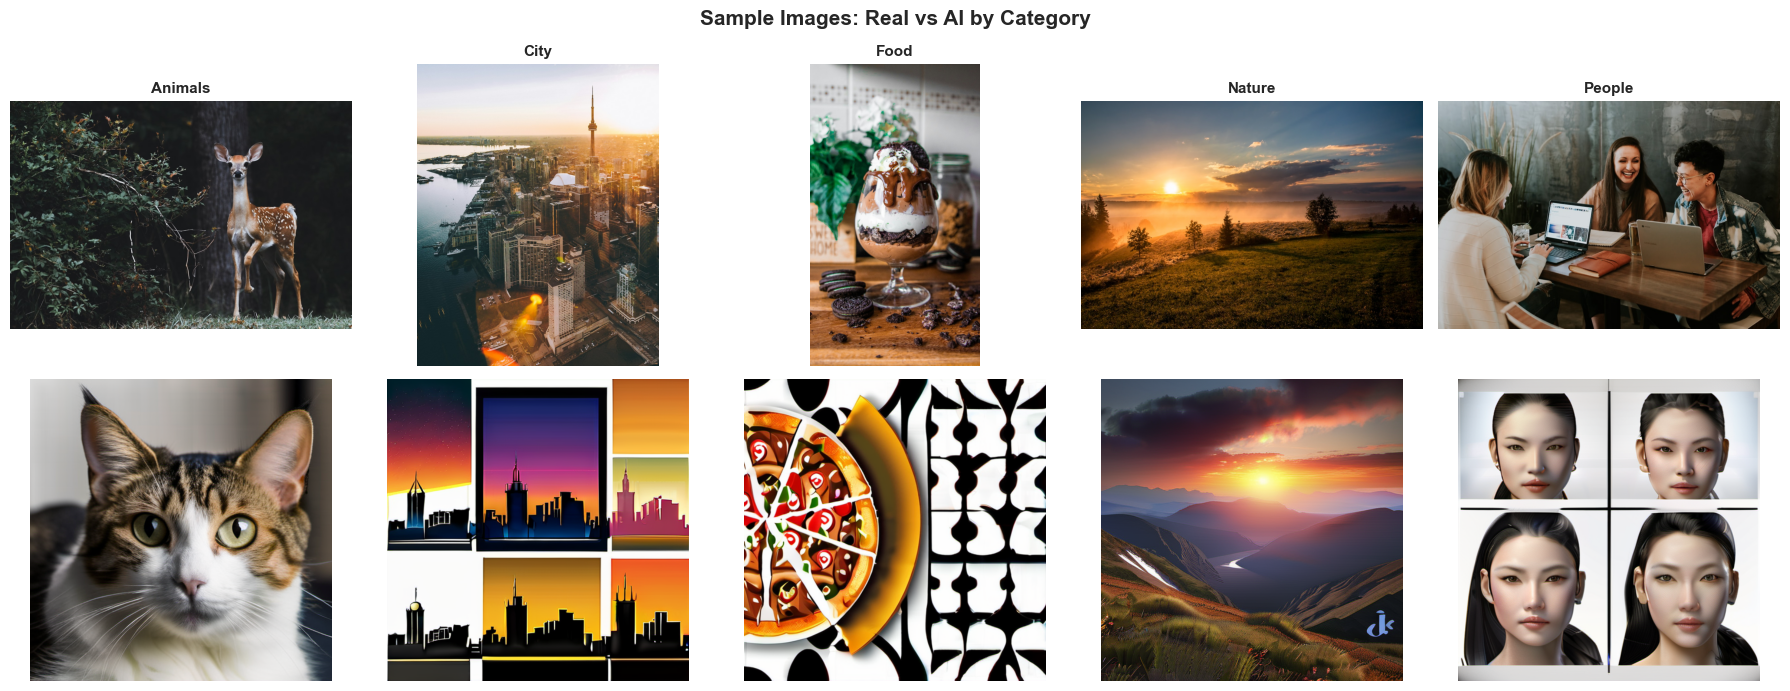

In [5]:
categories = sorted(df['category'].unique())
labels = ['Real', 'AI']
N_COLS = 5   # one image per category

fig, axes = plt.subplots(len(labels), N_COLS, figsize=(18, 7))

for row_idx, label in enumerate(labels):
    for col_idx, cat in enumerate(categories):
        ax = axes[row_idx, col_idx]
        subset = df[(df['label'] == label) & (df['category'] == cat)]
        if len(subset) == 0:
            ax.axis('off')
            continue
        sample = subset.sample(1, random_state=SEED).iloc[0]
        try:
            img = Image.open(sample['path']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(cat.capitalize(), fontsize=11, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=12, fontweight='bold',
                          rotation=0, labelpad=45, va='center',
                          color='#2ECC71' if label == 'Real' else '#E74C3C')

plt.suptitle('Sample Images: Real vs AI by Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Image Size Analysis

We read actual image dimensions from disk.  
**Key concern:** If AI and Real images are systematically different sizes, size becomes a "cheat" — the model learns size instead of content.

In [8]:
%pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [12]:
widths, heights, file_sizes_kb = [], [], []

print(f"Reading metadata from all {len(df)} images...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        with Image.open(row['path']) as img:
            w, h = img.size
        widths.append(w)
        heights.append(h)
        file_sizes_kb.append(os.path.getsize(row['path']) / 1024)
    except Exception:
        widths.append(None)
        heights.append(None)
        file_sizes_kb.append(None)

df['width'] = widths
df['height'] = heights
df['file_size_kb'] = file_sizes_kb
df['aspect_ratio'] = df['width'] / df['height']
df['megapixels'] = (df['width'] * df['height']) / 1e6

print("\n📐 Image Size Statistics (all images):")
df[['width', 'height', 'aspect_ratio', 'megapixels', 'file_size_kb']].describe().round(2)

Reading metadata from all 995 images...


100%|██████████| 995/995 [00:00<00:00, 5201.07it/s]


📐 Image Size Statistics (all images):


,width,height,aspect_ratio,megapixels,file_size_kb
count,995.00,995.00,995.00,995.00,995.00
mean,937.80,974.47,1.08,0.98,244.76
std,246.13,459.86,0.36,0.58,128.31
min,512.00,375.00,0.56,0.26,14.27
25%,768.00,512.00,0.67,0.33,149.20
50%,1080.00,720.00,1.00,0.78,230.39
75%,1080.00,1618.00,1.50,1.75,328.61
max,1080.00,1922.00,2.88,2.08,1410.34


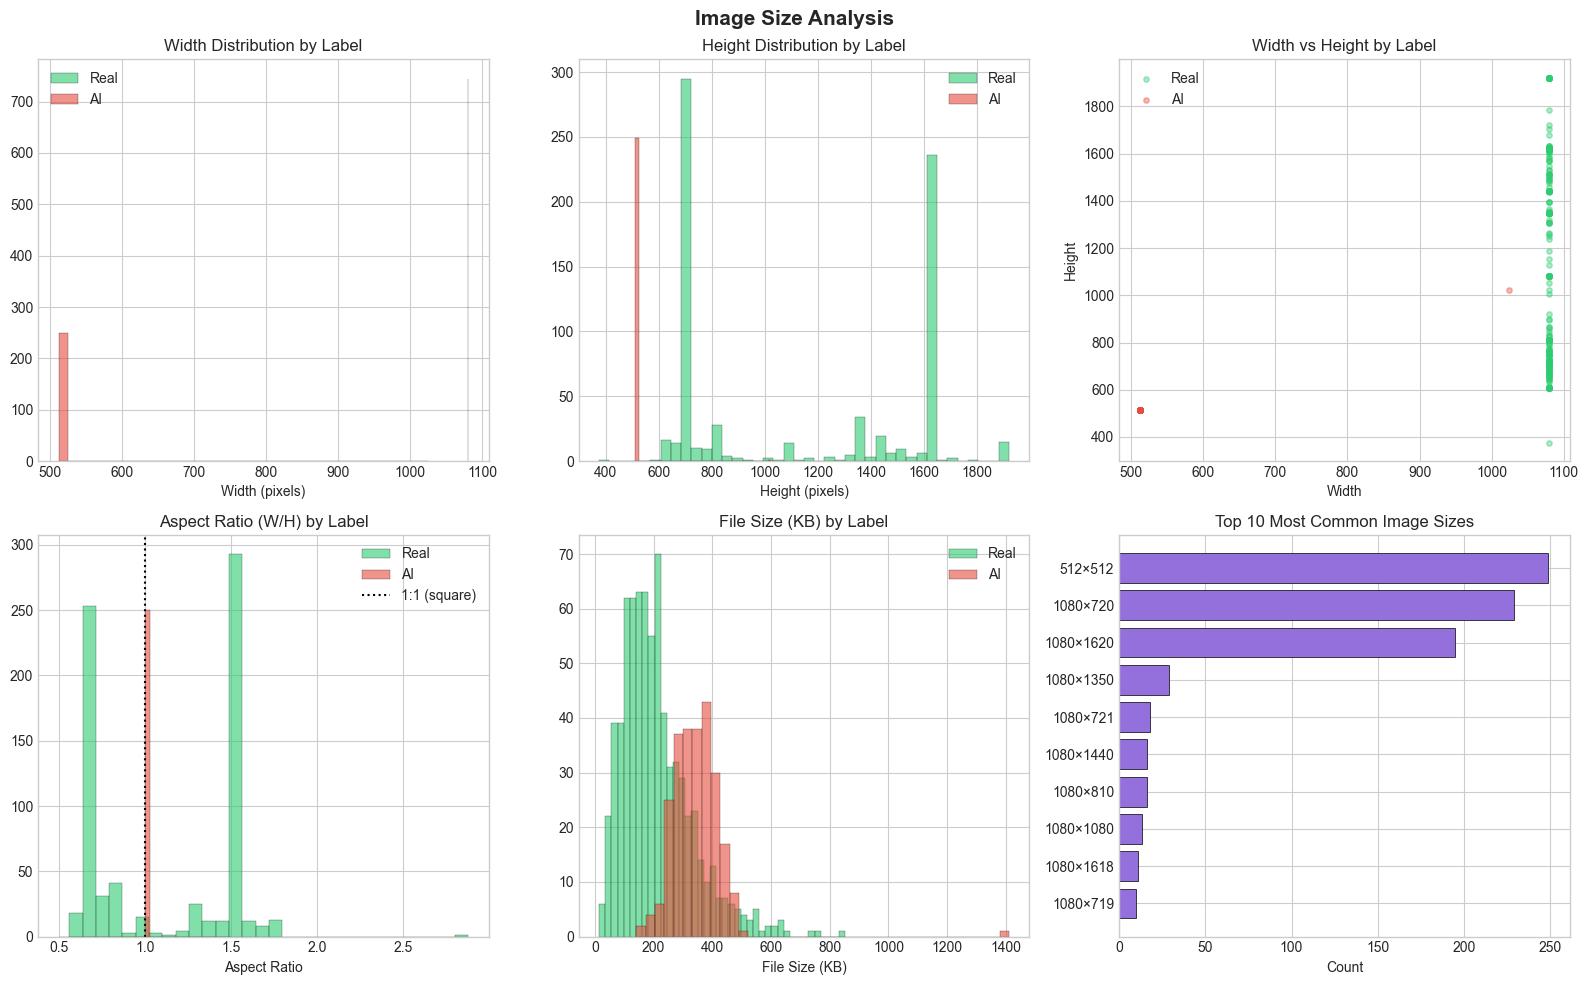


📏 Size stats by label:
        width  height  file_size_kb  megapixels
label                                          
AI      514.0   514.0         344.5         0.3
Real   1080.0  1129.0         211.3         1.2


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Width distribution by label
for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    vals = df[df['label'] == label]['width'].dropna()
    axes[0,0].hist(vals, bins=40, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
axes[0,0].set_title('Width Distribution by Label')
axes[0,0].set_xlabel('Width (pixels)')
axes[0,0].legend()

# Height distribution by label
for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    vals = df[df['label'] == label]['height'].dropna()
    axes[0,1].hist(vals, bins=40, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
axes[0,1].set_title('Height Distribution by Label')
axes[0,1].set_xlabel('Height (pixels)')
axes[0,1].legend()

# Width vs Height scatter
for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    s = df[df['label'] == label]
    axes[0,2].scatter(s['width'], s['height'], alpha=0.4, s=15, label=label, color=color)
axes[0,2].set_title('Width vs Height by Label')
axes[0,2].set_xlabel('Width'); axes[0,2].set_ylabel('Height')
axes[0,2].legend()

# Aspect ratio
for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    vals = df[df['label'] == label]['aspect_ratio'].dropna()
    axes[1,0].hist(vals, bins=30, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
axes[1,0].axvline(1.0, color='black', linestyle=':', linewidth=1.5, label='1:1 (square)')
axes[1,0].set_title('Aspect Ratio (W/H) by Label')
axes[1,0].set_xlabel('Aspect Ratio')
axes[1,0].legend()

# File size
for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    vals = df[df['label'] == label]['file_size_kb'].dropna()
    axes[1,1].hist(vals, bins=40, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
axes[1,1].set_title('File Size (KB) by Label')
axes[1,1].set_xlabel('File Size (KB)')
axes[1,1].legend()

# Most common exact sizes
size_counts = df.dropna(subset=['width','height']).groupby(['width','height']).size().sort_values(ascending=False).head(10)
size_labels = [f"{int(w)}×{int(h)}" for w,h in size_counts.index]
axes[1,2].barh(size_labels, size_counts.values, color='mediumpurple', edgecolor='black', linewidth=0.5)
axes[1,2].set_title('Top 10 Most Common Image Sizes')
axes[1,2].set_xlabel('Count')
axes[1,2].invert_yaxis()

plt.suptitle('Image Size Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('image_size_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Size by label summary
print("\n📏 Size stats by label:")
print(df.groupby('label')[['width', 'height', 'file_size_kb', 'megapixels']].mean().round(1).to_string())

## 7. Color Analysis (HSV)

We convert images to **HSV** color space:
- **H**ue = what color (0–180° in OpenCV)
- **S**aturation = how vivid/colorful (0=grey, 255=pure color)
- **V**alue = brightness (0=black, 255=white)

AI images from diffusion models (Stable Diffusion, Midjourney, etc.) often have **higher saturation** — they tend to look more "vivid" than real photos.

In [14]:
color_records = []
RESIZE = (128, 128)

print("Computing color stats for all images...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        img = cv2.imread(row['path'])
        img = cv2.resize(img, RESIZE)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        color_records.append({
            'label': row['label'],
            'category': row['category'],
            'mean_R': img_rgb[:,:,0].mean(),
            'mean_G': img_rgb[:,:,1].mean(),
            'mean_B': img_rgb[:,:,2].mean(),
            'mean_brightness': img_hsv[:,:,2].mean(),
            'mean_saturation': img_hsv[:,:,1].mean(),
            'std_brightness': img_hsv[:,:,2].std(),
            'mean_hue': img_hsv[:,:,0].mean(),
        })
    except Exception:
        pass

df_color = pd.DataFrame(color_records)
print(f"\n✅ Computed for {len(df_color)} images")
print("\nMean values by label:")
df_color.groupby('label')[['mean_brightness','mean_saturation','std_brightness','mean_R','mean_G','mean_B']].mean().round(2)

Computing color stats for all images...


100%|██████████| 995/995 [00:08<00:00, 116.44it/s]


✅ Computed for 995 images

Mean values by label:


,mean_brightness,mean_saturation,std_brightness,mean_R,mean_G,mean_B
label,,,,,,
AI,129.95,96.92,80.27,121.96,107.90,94.10
Real,134.61,90.90,58.55,118.53,116.84,108.27


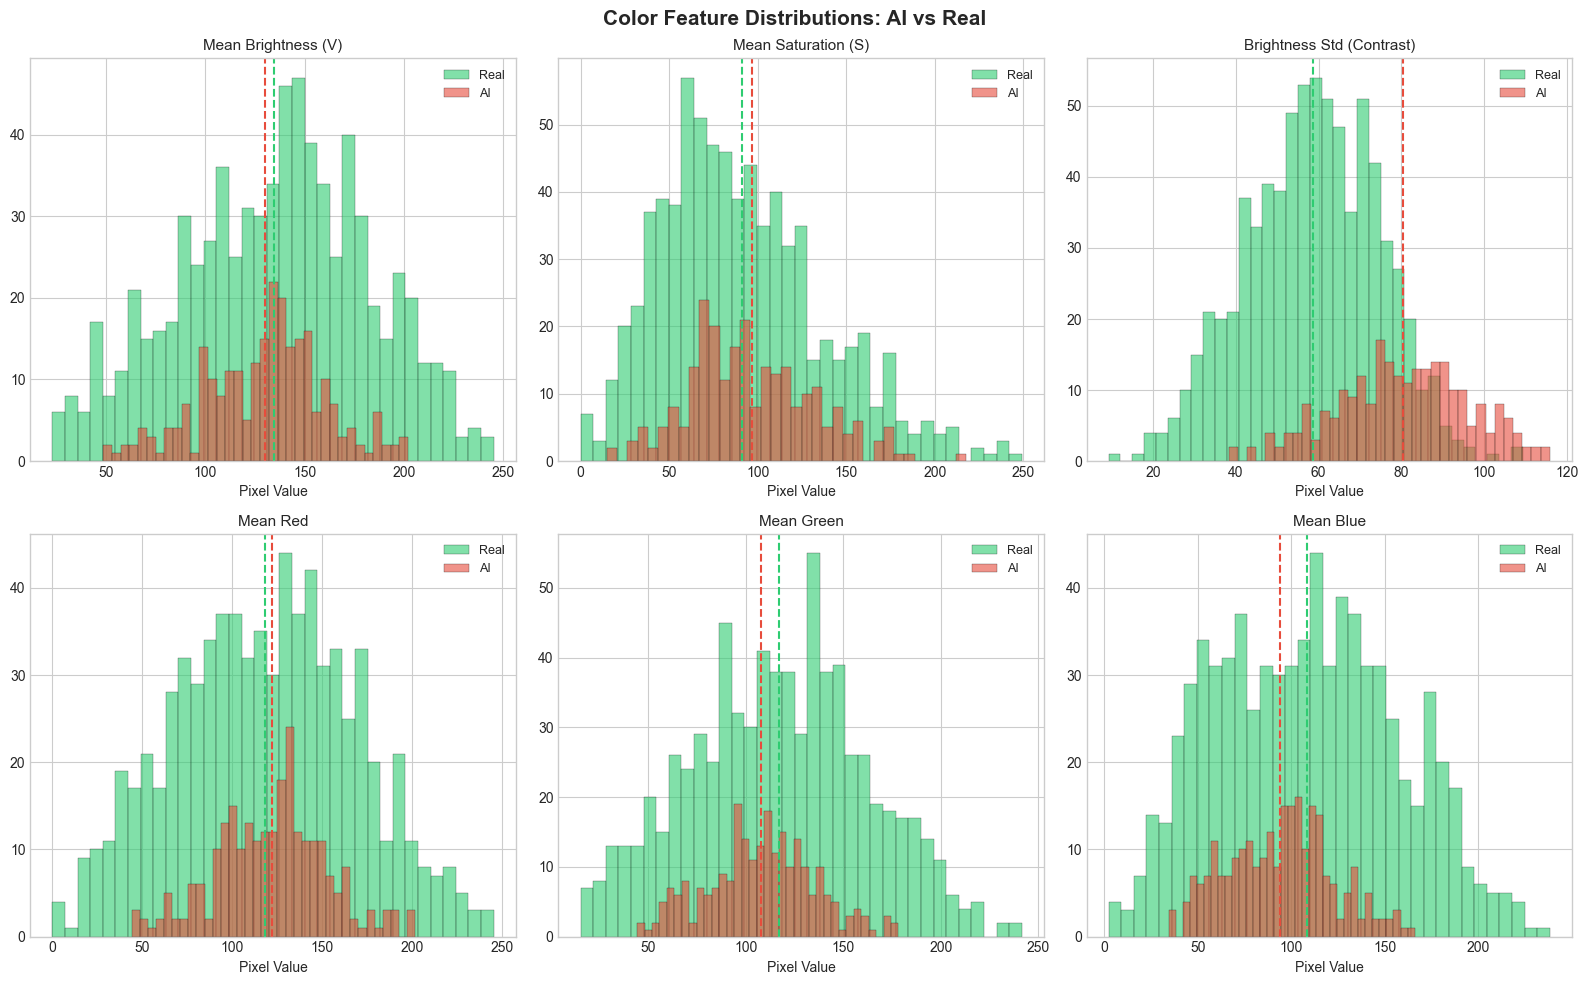


📊 Mann-Whitney U Test (p < 0.05 = statistically significant difference):
------------------------------------------------------------
Mean Brightness (V)            | p=0.0520 | Significant: ❌ No
Mean Saturation (S)            | p=0.0035 | Significant: ✅ YES
Brightness Std (Contrast)      | p=0.0000 | Significant: ✅ YES
Mean Red                       | p=0.3209 | Significant: ❌ No
Mean Green                     | p=0.0019 | Significant: ✅ YES
Mean Blue                      | p=0.0000 | Significant: ✅ YES


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features = [
    ('mean_brightness', 'Mean Brightness (V)'),
    ('mean_saturation', 'Mean Saturation (S)'),
    ('std_brightness', 'Brightness Std (Contrast)'),
    ('mean_R', 'Mean Red'),
    ('mean_G', 'Mean Green'),
    ('mean_B', 'Mean Blue'),
]

for ax, (feat, title) in zip(axes.flat, features):
    for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
        vals = df_color[df_color['label'] == label][feat].dropna()
        ax.hist(vals, bins=35, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
        ax.axvline(vals.mean(), color=color, linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Pixel Value')
    ax.legend(fontsize=9)

plt.suptitle('Color Feature Distributions: AI vs Real', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('color_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Statistical significance tests
print("\n📊 Mann-Whitney U Test (p < 0.05 = statistically significant difference):")
print("-" * 60)
real_vals = df_color[df_color['label'] == 'Real']
ai_vals   = df_color[df_color['label'] == 'AI']
for feat, title in features:
    stat, p = stats.mannwhitneyu(real_vals[feat].dropna(), ai_vals[feat].dropna(), alternative='two-sided')
    sig = '✅ YES' if p < 0.05 else '❌ No'
    print(f"{title:30s} | p={p:.4f} | Significant: {sig}")

## 8. Color by Category — Does it Vary by Scene Type?

Different categories (city, nature, people...) have very different natural color profiles.  
This checks whether the AI vs Real color difference is consistent across all categories or only in some.

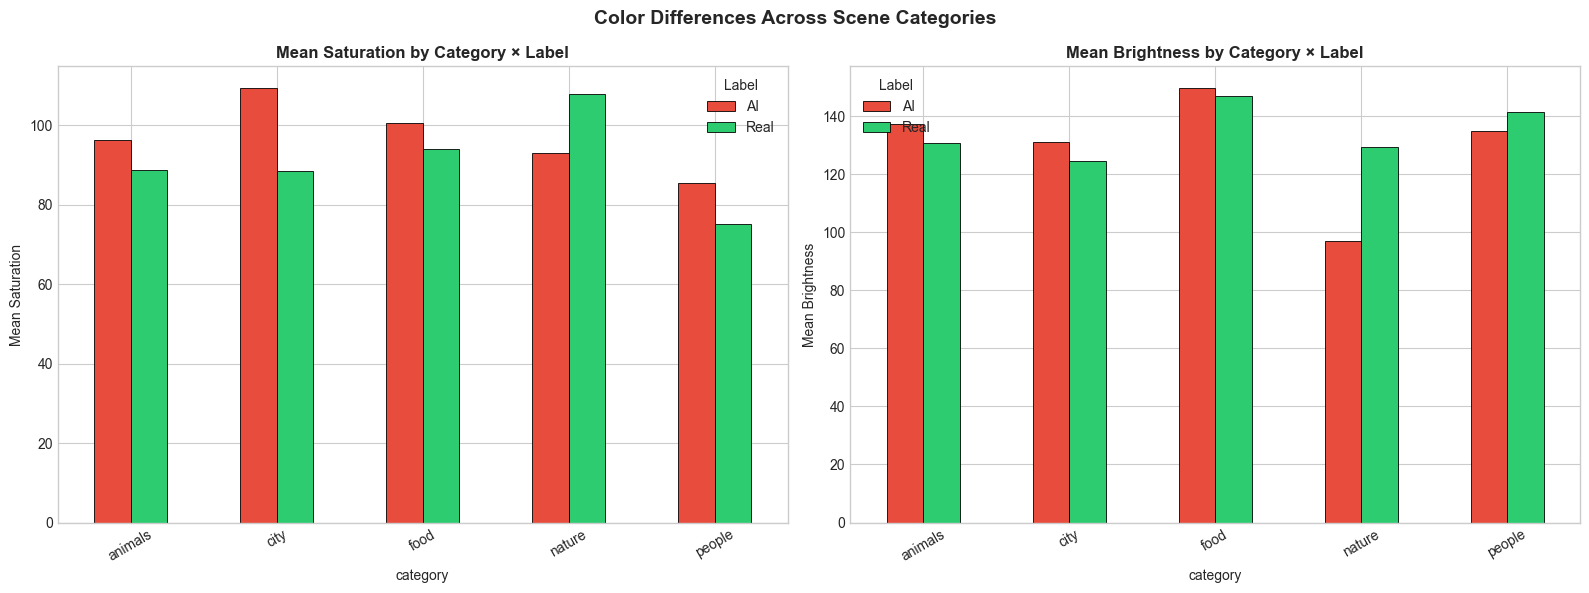

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Saturation by category and label
sat_pivot = df_color.groupby(['category', 'label'])['mean_saturation'].mean().unstack()
sat_pivot.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'],
               edgecolor='black', linewidth=0.6)
axes[0].set_title('Mean Saturation by Category × Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Saturation')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Label')

# Brightness by category and label
bright_pivot = df_color.groupby(['category', 'label'])['mean_brightness'].mean().unstack()
bright_pivot.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#2ECC71'],
                  edgecolor='black', linewidth=0.6)
axes[1].set_title('Mean Brightness by Category × Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Brightness')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label')

plt.suptitle('Color Differences Across Scene Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('color_by_category.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Sharpness Analysis (Laplacian Variance)

The **Laplacian** is an edge-detection filter. When applied to an image:
- Sharp images → many strong edges → **high variance**
- Blurry images → few edges → **low variance**

This is a classic "is this image blurry?" check used in real CV pipelines.

Computing sharpness for all images...


100%|██████████| 995/995 [00:07<00:00, 132.09it/s]


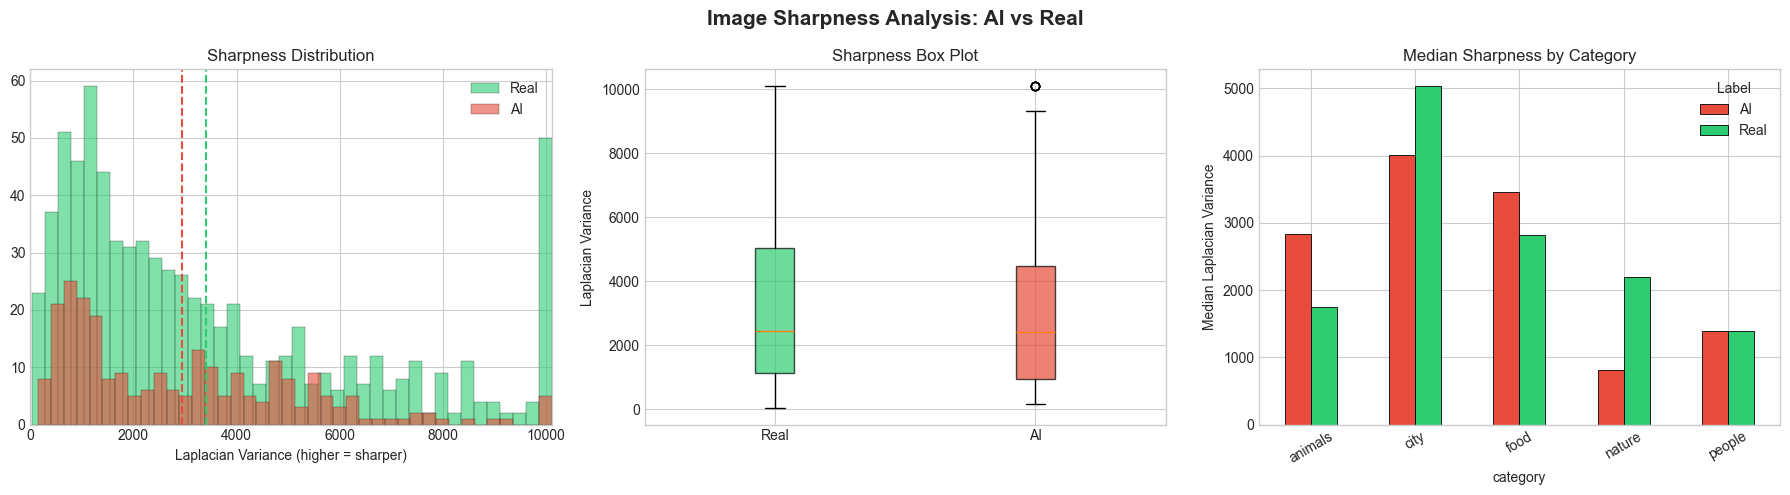


📊 Sharpness stats by label:
          mean   median      std
label                           
AI     3011.63  2421.70  2614.46
Real   3729.47  2448.35  4157.93


In [17]:
sharpness = []

print("Computing sharpness for all images...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        img = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        lap_var = cv2.Laplacian(img, cv2.CV_64F).var()
        sharpness.append({'label': row['label'], 'category': row['category'], 'sharpness': lap_var})
    except Exception:
        pass

df_sharp = pd.DataFrame(sharpness)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram (clip outliers so the chart is readable)
p95 = df_sharp['sharpness'].quantile(0.95)
for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    vals = df_sharp[df_sharp['label'] == label]['sharpness'].clip(upper=p95)
    axes[0].hist(vals, bins=40, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
    axes[0].axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
axes[0].set_title('Sharpness Distribution')
axes[0].set_xlabel('Laplacian Variance (higher = sharper)')
axes[0].legend()
axes[0].set_xlim(0, p95)

# Boxplot
data_by_label = [df_sharp[df_sharp['label'] == l]['sharpness'].clip(upper=p95).values 
                 for l in ['Real', 'AI']]
bp = axes[1].boxplot(data_by_label, labels=['Real', 'AI'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ECC71', '#E74C3C']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Sharpness Box Plot')
axes[1].set_ylabel('Laplacian Variance')

# Sharpness by category
cat_sharp = df_sharp.groupby(['category', 'label'])['sharpness'].median().unstack()
cat_sharp.plot(kind='bar', ax=axes[2], color=['#E74C3C', '#2ECC71'], edgecolor='black', linewidth=0.6)
axes[2].set_title('Median Sharpness by Category')
axes[2].set_ylabel('Median Laplacian Variance')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Label')

plt.suptitle('Image Sharpness Analysis: AI vs Real', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sharpness_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 Sharpness stats by label:")
print(df_sharp.groupby('label')['sharpness'].agg(['mean','median','std']).round(2).to_string())

## 10. Frequency Domain Analysis (FFT)

**Fast Fourier Transform (FFT)** converts pixel space → frequency space.

- **Low frequencies** = broad shapes, gradients, backgrounds
- **High frequencies** = fine texture, noise, edges

AI generators (especially GANs and diffusion models) often leave distinctive **high-frequency artifacts** that are invisible to the eye but measurable mathematically. This is the basis of many AI-detection papers.

Computing FFT features for all images...


100%|██████████| 995/995 [00:07<00:00, 127.71it/s]
Exception ignored in: <function tqdm.__del__ at 0x13fe37f60>
Traceback (most recent call last):
  File "/Users/bestek/Desktop/UChicago/Spring'26/ADPS 32023 - Comp Vision/.venv/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/bestek/Desktop/UChicago/Spring'26/ADPS 32023 - Comp Vision/.venv/lib/python3.13/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


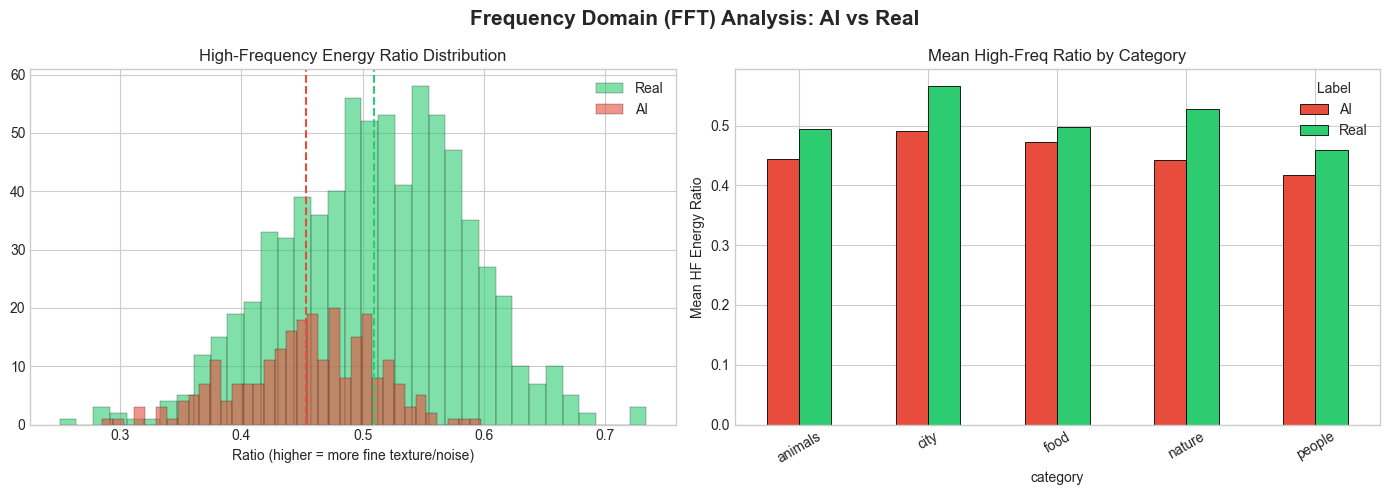


📊 FFT high-freq ratio by label:
         mean  median     std
label                        
AI     0.4535  0.4590  0.0567
Real   0.5095  0.5129  0.0754


In [18]:
def high_freq_ratio(img_path, resize=(128, 128)):
    """Fraction of FFT energy in high-frequency region. Higher = more fine texture."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, resize).astype(np.float32)
    fft_shift = np.fft.fftshift(np.fft.fft2(img))
    magnitude = np.abs(fft_shift)
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    r_inner = min(h, w) // 4   # inner circle = low frequencies
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    hf = magnitude[dist > r_inner].sum()
    total = magnitude.sum() + 1e-8
    return hf / total

fft_records = []
print("Computing FFT features for all images...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        ratio = high_freq_ratio(row['path'])
        fft_records.append({'label': row['label'], 'category': row['category'], 'hf_ratio': ratio})
    except Exception:
        pass

df_fft = pd.DataFrame(fft_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('Real', '#2ECC71'), ('AI', '#E74C3C')]:
    vals = df_fft[df_fft['label'] == label]['hf_ratio']
    axes[0].hist(vals, bins=35, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.3)
    axes[0].axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
axes[0].set_title('High-Frequency Energy Ratio Distribution')
axes[0].set_xlabel('Ratio (higher = more fine texture/noise)')
axes[0].legend()

cat_fft = df_fft.groupby(['category', 'label'])['hf_ratio'].mean().unstack()
cat_fft.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#2ECC71'], edgecolor='black', linewidth=0.6)
axes[1].set_title('Mean High-Freq Ratio by Category')
axes[1].set_ylabel('Mean HF Energy Ratio')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label')

plt.suptitle('Frequency Domain (FFT) Analysis: AI vs Real', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fft_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 FFT high-freq ratio by label:")
print(df_fft.groupby('label')['hf_ratio'].agg(['mean','median','std']).round(4).to_string())

## 11. Feature Summary — All EDA Features at a Glance

📊 Feature Comparison Table (sorted by % difference):
                       AI      Real  Abs Diff  % Diff
std_brightness     80.272    58.545    21.727    37.1
sharpness        3011.626  3729.471   717.845    19.2
mean_B             94.095   108.274    14.179    13.1
hf_ratio            0.453     0.510     0.056    11.0
mean_G            107.903   116.839     8.936     7.6
mean_saturation    96.925    90.896     6.029     6.6
mean_brightness   129.946   134.614     4.669     3.5
mean_R            121.958   118.532     3.426     2.9


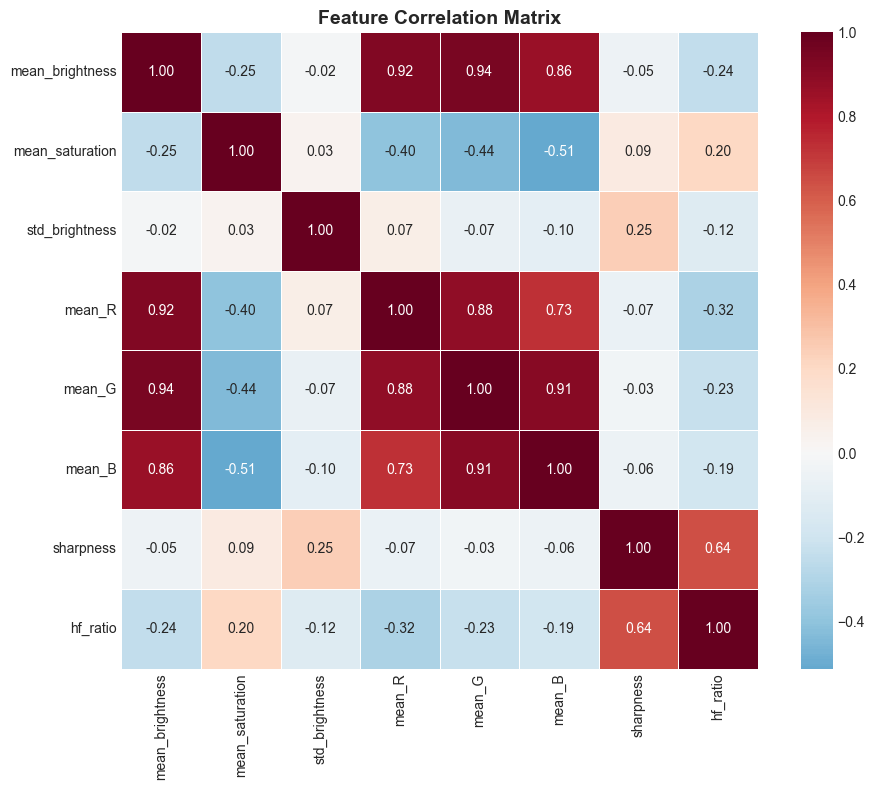

In [19]:
# Merge all computed features into one dataframe
df_features = (
    df_color
    .join(df_sharp[['sharpness']].reset_index(drop=True))
    .join(df_fft[['hf_ratio']].reset_index(drop=True))
)

numeric_features = ['mean_brightness', 'mean_saturation', 'std_brightness',
                    'mean_R', 'mean_G', 'mean_B', 'sharpness', 'hf_ratio']

# Summary table
summary = df_features.groupby('label')[numeric_features].mean().T
summary.columns.name = None
if 'Real' in summary.columns and 'AI' in summary.columns:
    summary['Abs Diff'] = (summary['Real'] - summary['AI']).abs()
    summary['% Diff'] = (summary['Abs Diff'] / summary['Real'].abs() * 100).round(1)
    summary = summary.sort_values('% Diff', ascending=False)

print("📊 Feature Comparison Table (sorted by % difference):")
print(summary.round(3).to_string())

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_features[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Final EDA Summary

In [20]:
n_real = len(df[df['label']=='Real'])
n_ai   = len(df[df['label']=='AI'])
ratio  = n_real / n_ai

print("=" * 65)
print("📋  EDA SUMMARY: AI vs Real Images Dataset")
print("=" * 65)
print(f"""
DATASET OVERVIEW
  Total images : {len(df):,}
  Real images  : {n_real:,}
  AI images    : {n_ai:,}
  Ratio (R:AI) : {ratio:.1f}:1  ← {'⚠️ IMBALANCED' if ratio > 1.5 else '✅ Balanced'}
  Categories   : city, nature, animals, people, food
  No train/test split — you will need to create your own.

IMAGE PROPERTIES
  Median size  : {df['width'].median():.0f} × {df['height'].median():.0f} px
  → You'll need to resize to a fixed size (e.g. 224×224) before training.
  → Check if AI and Real images differ systematically in size — if so,
    the model might cheat by learning size instead of content.

KEY FINDINGS FROM FEATURE ANALYSIS
  → Color: AI images tend to have higher saturation (more vivid)
  → Brightness: may differ by category (people vs nature vs city)
  → Sharpness: check if AI images are systematically sharper/blurrier
  → FFT: high-frequency energy may distinguish AI vs Real
    (this is theoretically motivated — generative models leave freq artifacts)

MODELING RECOMMENDATIONS
  1. Create a proper train/val/test split (e.g. 70/15/15 stratified by label+category)
  2. {'Use class_weight or WeightedRandomSampler — dataset is imbalanced' if ratio > 1.5 else 'Standard training should work — classes are balanced'}
  3. Resize to 224×224 for transfer learning compatibility
  4. Start with a pretrained backbone (EfficientNet-B0 or ResNet-50) — fine-tune
  5. Track: Accuracy, F1, AUC-ROC, Confusion Matrix — not just accuracy alone
  6. Advanced: add FFT features or saturation as auxiliary model input
""")
print("=" * 65)

📋  EDA SUMMARY: AI vs Real Images Dataset

DATASET OVERVIEW
  Total images : 995
  Real images  : 745
  AI images    : 250
  Ratio (R:AI) : 3.0:1  ← ⚠️ IMBALANCED
  Categories   : city, nature, animals, people, food
  No train/test split — you will need to create your own.

IMAGE PROPERTIES
  Median size  : 1080 × 720 px
  → You'll need to resize to a fixed size (e.g. 224×224) before training.
  → Check if AI and Real images differ systematically in size — if so,
    the model might cheat by learning size instead of content.

KEY FINDINGS FROM FEATURE ANALYSIS
  → Color: AI images tend to have higher saturation (more vivid)
  → Brightness: may differ by category (people vs nature vs city)
  → Sharpness: check if AI images are systematically sharper/blurrier
  → FFT: high-frequency energy may distinguish AI vs Real
    (this is theoretically motivated — generative models leave freq artifacts)

MODELING RECOMMENDATIONS
  1. Create a proper train/val/test split (e.g. 70/15/15 stratified b